# Aircraft Pitch Control using Reinforcement Learning

This notebook demonstrates the development and training of a reinforcement learning agent to control the longitudinal pitch of an aircraft. It utilizes a custom Gymnasium environment to simulate aircraft dynamics and trains an agent using the Stable Baselines3 library.

In [ ]:
# Cell 1: Installations
!pip install gymnasium stable-baselines3 sb3-contrib shimmy scipy matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.2/93.2 kB 7.6 MB/s eta 0:00:00


In [ ]:
# Cell 2: Imports
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from gymnasium import spaces

# RL Algorithms
from stable_baselines3 import PPO, SAC
from sb3_contrib import TQC
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import EvalCallback

print("Libraries imported successfully.")

Libraries imported successfully.


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


MDP == Markov Decision Process

In [ ]:

A2 = 6.492
A1 = -3.316
A0 = -1.067e-12
B1 = 40.32
B0 = 71.36


class AircraftPitchEnv(gym.Env):
    """
    Aircraft longitudinal pitch control with:
      * normalized observations and actions
      * rate-limited elevator (ΔE)
      * shaped reward around tracking
      * success / crash terminations
    """

    metadata = {"render_modes": ["human"], "render_fps": 30}

    def __init__(
        self,
        dt: float = 0.02,
        max_episode_seconds: float = 15.0,
        theta_ref: float = 0.1,   # target pitch [rad] (~5.7 deg)
        max_deflection_deg: float = 25.0,
        max_deflection_rate_deg_per_s: float = 60.0,
        theta_limit_deg: float = 35.0,  # tighten a bit to keep dynamics reasonable
        # reward shaping
        theta_error_tol_deg: float = 2.0,
        theta_dot_tol_deg: float = 5.0,
        success_hold_time: float = 3.0,  # must hold target for this long [s]
        success_bonus: float = 10.0,
        crash_penalty: float = -10.0,
        seed: int | None = None,
    ):
        super().__init__()

        self.dt = dt
        self.max_steps = int(max_episode_seconds / dt)
        self.theta_ref = theta_ref

        # Limits / scales (physical)
        self.max_deflection = np.deg2rad(max_deflection_deg)
        self.max_deflection_rate = np.deg2rad(max_deflection_rate_deg_per_s)
        self.theta_limit = np.deg2rad(theta_limit_deg)

        # For reward tolerance
        self.theta_error_tol = np.deg2rad(theta_error_tol_deg)
        self.theta_dot_tol = np.deg2rad(theta_dot_tol_deg)

        # Success must be held for this many steps
        self.success_hold_steps = int(success_hold_time / dt)
        self.success_bonus = success_bonus
        self.crash_penalty = crash_penalty

        # ---- Normalization scales (physical → [-1,1]) ---- # aquí se definen las escalas para normalizar las observaciones
        self.theta_scale = self.theta_limit          # rad. Esto esla theta máxima que se espera que el sistema alcance, usada para normalizar theta a [-1,1]
        self.theta_dot_scale = 2.0 * self.theta_dot_tol   # rad/s
        self.theta_ddot_scale = 50.0                 # rad/s^2
        self.theta_ref_scale = max(abs(self.theta_ref), np.deg2rad(10.0))

        # Normalized observation space
        self.observation_space = spaces.Box(
            low=-1.0, high=1.0, shape=(4,), dtype=np.float32
        )

        # Normalized action space: a_norm ∈ [-1,1]
        self.action_space = spaces.Box( # aquí solo tiene una componente porque el agente solo controla el elevator, no hay otras superficies de control
            low=-1.0, high=1.0, shape=(1,), dtype=np.float32
        )

        self._rng = np.random.default_rng(seed)
        self.state = None
        self.prev_u = 0.0
        self.current_step = 0
        self._success_counter = 0  # consecutive steps inside success region

        self._history = None

    def seed(self, seed=None): # el seed es opcional para permitir resetear el RNG sin crear uno nuevo
        self._rng = np.random.default_rng(seed)

    # ---------------- Dynamics -----------------
    def _derivatives(self, x, u, u_prev): # esto es para calcular x_dot = f(x,u) usando la ecuación diferencial dada, con u_prev para el término de u_dot.
        # Son las derivadas de theta, theta_dot y theta_ddot, que se usan para integrar el estado con Euler en el step() method.
        theta, theta_dot, theta_ddot = x
        dt = self.dt
        u_dot = (u - u_prev) / dt

        theta_3dot = (
            -A2 * theta_ddot
            - A1 * theta_dot
            - A0 * theta
            + B1 * u_dot
            + B0 * u
        )
        return np.array([theta_dot, theta_ddot, theta_3dot], dtype=np.float32)

    def _get_obs(self):
        theta, theta_dot, theta_ddot = self.state
        obs = np.array(
            [
                theta / self.theta_scale,
                theta_dot / self.theta_dot_scale,
                theta_ddot / self.theta_ddot_scale,
                self.theta_ref / self.theta_ref_scale,
            ],
            dtype=np.float32,
        )
        return np.clip(obs, -1.0, 1.0) # esto nos permite asegurarnos que estamos entre -1 y 1.

    # ---------------- Gym API ------------------
    def reset(self, *, seed=None, options=None):
        if seed is not None:
            self.seed(seed)

        # small random initial condition
        theta0 = self._rng.normal(0.0, np.deg2rad(2.0))
        theta_dot0 = self._rng.normal(0.0, np.deg2rad(5.0))
        theta_ddot0 = self._rng.normal(0.0, np.deg2rad(10.0))

        self.state = np.array([theta0, theta_dot0, theta_ddot0], dtype=np.float32) # lo más importante es que el estado inicial tenga una pequeña perturbación.
        self.prev_u = 0.0
        self.current_step = 0
        self._success_counter = 0

        self._history = {
            "t": [0.0],
            "theta": [theta0],
            "theta_ref": [self.theta_ref],
            "theta_dot": [theta_dot0],
            "theta_ddot": [theta_ddot0],
            "u": [0.0],
            "reward": [],
        }

        return self._get_obs(), {}

    def step(self, action):
        # --- map normalized action to physical elevator and apply rate limit ---
        a_norm = float(np.clip(action[0], -1.0, 1.0))
        u_desired = a_norm * self.max_deflection # denormalizamos la acción a un valor físico de deflexión del elevator, que es lo que realmente controla el sistema. Esto es lo que el agente "quiere" hacer. Luego aplicamos un rate limit para asegurarnos de que el cambio en la deflexión no sea demasiado grande en un solo paso, lo que sería irrealista físicamente.

        max_du = self.max_deflection_rate * self.dt
        du = np.clip(u_desired - self.prev_u, -max_du, max_du)
        u = self.prev_u + du  # physical ΔE after rate limit

        # integrate dynamics
        x = self.state
        x_dot = self._derivatives(x, u, self.prev_u)
        x_next = x + self.dt * x_dot

        self.state = x_next
        u_prev = self.prev_u
        self.prev_u = u
        self.current_step += 1

        obs = self._get_obs()

        # --------- Reward shaping ----------
        theta, theta_dot, _ = self.state
        theta_error = theta - self.theta_ref

        # normalized tracking errors
        e_theta_n = theta_error / self.theta_error_tol
        e_theta_dot_n = theta_dot / self.theta_dot_tol

        r_track = -(e_theta_n**2 + 0.1 * e_theta_dot_n**2)

        # normalize control and rate for penalty
        u_n = u / self.max_deflection
        du_rate_n = (u - u_prev) / (self.max_deflection_rate * self.dt + 1e-8)
        r_control = -0.01 * (u_n**2) - 0.001 * (du_rate_n**2)

        reward = float(r_track + r_control)

        # --------- Termination logic ----------
        terminated = False
        truncated = False

        # crash if angle goes out of bounds
        if np.abs(theta) > self.theta_limit:
            terminated = True
            reward += self.crash_penalty

        # success region: near reference and low rate
        in_success_region = (
            np.abs(theta_error) < self.theta_error_tol
            and np.abs(theta_dot) < self.theta_dot_tol
        )

        if in_success_region:
            self._success_counter += 1
        else:
            self._success_counter = 0

        if self._success_counter >= self.success_hold_steps:
            terminated = True
            reward += self.success_bonus

        # timeout
        if self.current_step >= self.max_steps:
            truncated = True

        # log history
        if self._history is not None:
            t = self.current_step * self.dt
            self._history["t"].append(t)
            self._history["theta"].append(theta)
            self._history["theta_ref"].append(self.theta_ref)
            self._history["theta_dot"].append(theta_dot)
            self._history["theta_ddot"].append(self.state[2])
            self._history["u"].append(u)
            self._history["reward"].append(reward)

        return obs, reward, terminated, truncated, {}

    def render(self):
        if self._history is None:
            return
    def close(self):
        pass


In [ ]:
# Cell 4: Training with Normalized Observations (Standard Practice)

from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

# --- CONFIGURATION ---
ALGORITHM = "PPO"
TIMESTEPS = 600_000
# ---------------------

# 1. Create the base environment
env = AircraftPitchEnv()

# 2. Wrap it in a Vectorized Environment (Required for Normalization wrapper)
env = DummyVecEnv([lambda: env])

# 3. Apply Normalization
# This automatically scales observations and returns (rewards) to a standard normal distribution.
# norm_obs=True: Normalizes the state vector (Crucial for neural net performance)
# norm_reward=True: Normalizes rewards (Helps with gradient stability)
# env = VecNormalize(env, norm_obs=True, norm_reward=True, clip_obs=10.)

# 4. Initialize Agent
if ALGORITHM == "TQC":
    model = TQC("MlpPolicy", env, verbose=1, learning_rate=1e-3, top_quantiles_to_drop_per_net=2)
elif ALGORITHM == "PPO":
    model = PPO("MlpPolicy", env, verbose=2)
elif ALGORITHM == "SAC":
    model = SAC("MlpPolicy", env, verbose=1)

print(f"Training {ALGORITHM} with Normalized Observations...")
model.learn(total_timesteps=TIMESTEPS)

# 5. Save the Normalization Statistics!
# We need these stats to normalize inputs correctly during testing/inference.
model.save("aircraft_model")
# env.save("vec_normalize.pkl")
print("Training Complete and Model/Stats saved.")

Using cpu device
Training PPO with Normalized Observations...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    value_loss           | 6.66e+03     |
------------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 654         |
|    iterations           | 31          |
|    time_elapsed         | 97          |
|    total_timesteps      | 63488       |
| train/                  |             |
|    approx_kl            | 0.004180871 |
|    clip_fraction        | 0.016       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.31       |
|    explained_variance   | 2.38e-07    |
|    learning_rate        | 0.0003      |
|    loss                 | 5.78e+04    |
|    n_updates            | 300         |
|    policy_gradient_loss | -0.00258    |
|    std                  | 0.895       |
|    value_loss           | 1.46e+05    |
-----------------------------------------
------------------------------------------
| time/               

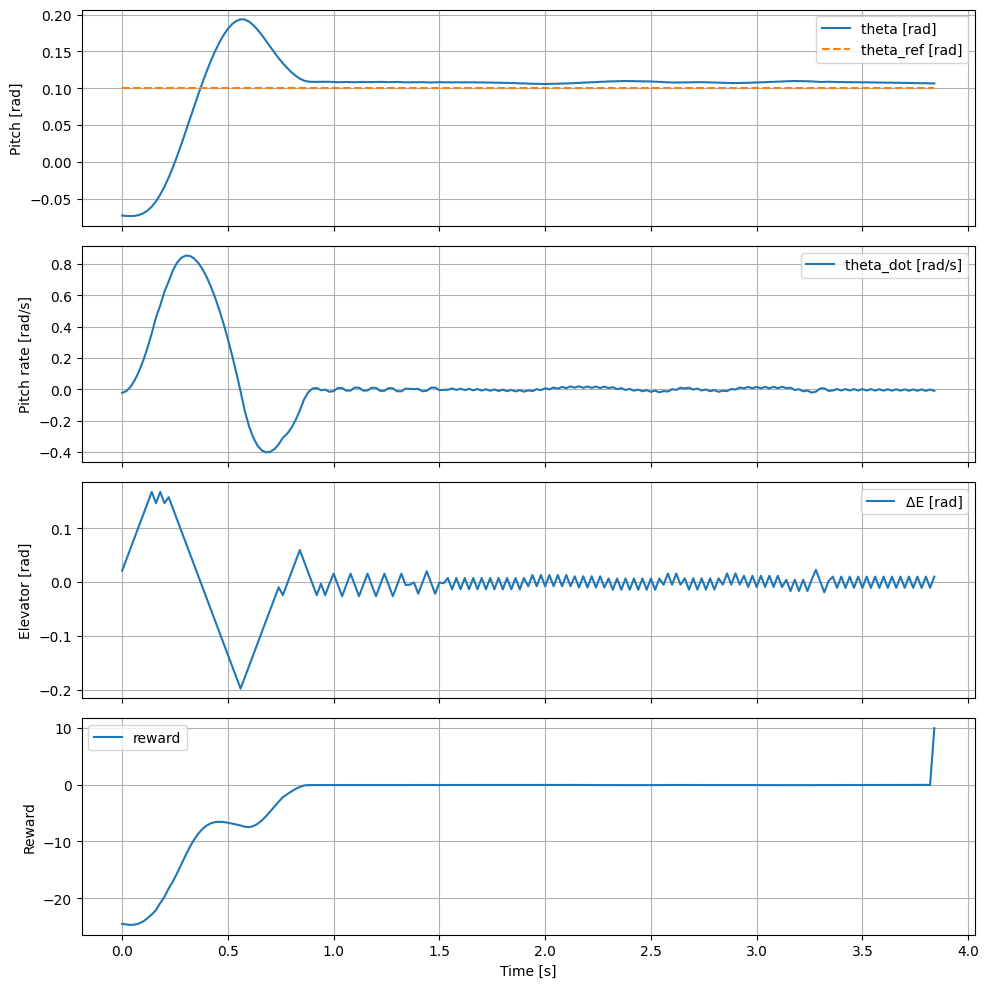

In [ ]:
# --- create a fresh environment (single, non-vectorized) ---
env = AircraftPitchEnv()
obs, info = env.reset()

theta_hist = []
theta_ref_hist = []
theta_dot_hist = []
theta_ddot_hist = []
u_hist = []
reward_hist = []
t_hist = []

terminated = False
truncated = False
step_idx = 0

while not (terminated or truncated):
    # Get action from trained agent (obs is already normalized)
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env.step(action)

    # Internal state is stored in physical units in env.state
    theta, theta_dot, theta_ddot = env.state
    u = env.prev_u

    t = step_idx * env.dt
    step_idx += 1

    # store histories
    t_hist.append(t)
    theta_hist.append(theta)
    theta_ref_hist.append(env.theta_ref)
    theta_dot_hist.append(theta_dot)
    theta_ddot_hist.append(theta_ddot)
    u_hist.append(u)
    reward_hist.append(reward)

# Convert to numpy arrays
t_hist = np.array(t_hist)
theta_hist = np.array(theta_hist)
theta_ref_hist = np.array(theta_ref_hist)
theta_dot_hist = np.array(theta_dot_hist)
theta_ddot_hist = np.array(theta_ddot_hist)
u_hist = np.array(u_hist)
reward_hist = np.array(reward_hist)

# --- Plot results ---
fig, axs = plt.subplots(4, 1, sharex=True, figsize=(10, 10))

# 1) Pitch angle tracking
axs[0].plot(t_hist, theta_hist, label="theta [rad]")
axs[0].plot(t_hist, theta_ref_hist, "--", label="theta_ref [rad]")
axs[0].set_ylabel("Pitch [rad]")
axs[0].grid(True)
axs[0].legend()

# 2) Pitch rate
axs[1].plot(t_hist, theta_dot_hist, label="theta_dot [rad/s]")
axs[1].set_ylabel("Pitch rate [rad/s]")
axs[1].grid(True)
axs[1].legend()

# 3) Elevator deflection
axs[2].plot(t_hist, u_hist, label="ΔE [rad]")
axs[2].set_ylabel("Elevator [rad]")
axs[2].grid(True)
axs[2].legend()

# 4) Instantaneous reward
axs[3].plot(t_hist, reward_hist, label="reward")
axs[3].set_ylabel("Reward")
axs[3].set_xlabel("Time [s]")
axs[3].grid(True)
axs[3].legend()

plt.tight_layout()
plt.show()

env.close()

